# 5. Run MCMC and inspect the posterior

This notebook recreates the model and mock `data` from the
[Quickstart](../quickstart.ipynb), so it can be run independently.
The forward solver predicts a variance. Inference additionally requires a
likelihood, sampling coordinates, priors and a sampling algorithm.


This notebook is self-contained. Install JeansPy with the `numpyro_cpu` and
`plotting` extras as described in the installation guide, then select that
environment as your Jupyter kernel and run cells from top to bottom.
Saved outputs are an example run; timings and short-chain results can vary.

## Setup

Run this setup in a fresh kernel. It defines all objects used below.

The generalized NFW halo uses `ZhaoModel` with fixed `a=1`, `b=3`
and an untruncated cutoff. Its inner slope `g` is sampled in the
inference examples; `truth["g"]=1` generates standard-NFW mocks.

In [1]:
import os
os.environ.setdefault("JEANSPY_JAX_PLATFORM", "cpu")
os.environ.setdefault("JEANSPY_JAX_ENABLE_X64", "true")

# The example uses no progress widgets; ignore only their optional-import warning.
import warnings
warnings.filterwarnings("ignore", message="IProgress not found.*")

# Import JeansPy before JAX so its runtime settings take effect.
from jeanspy.model_numpyro import (
    DSphModel, PlummerModel, ZhaoModel, ConstantAnisotropyModel,
)
from jeanspy.sampler_numpyro import JeansLikelihoodModel, ParameterSpec
import jax
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, init_to_value
import numpy as np
import matplotlib.pyplot as plt

model = DSphModel(submodels={
    "StellarModel": PlummerModel(),
    "DMModel": ZhaoModel(),
    "AnisotropyModel": ConstantAnisotropyModel(),
})
fixed = dict(re_pc=200., a=1., b=3., r_t_pc=np.inf)
truth = dict(**fixed, rs_pc=500., rhos_Msunpc3=.1, g=1., beta_ani=0.)
options = dict(backend="kernel", n_u=128, n_kernel=32,
               dm_mass_method="numeric", dm_mass_n_steps=128)

In [2]:
rng = np.random.default_rng(123)
u = rng.uniform(size=32)
R_pc = 200. * np.sqrt(u / (1. - u))  # Projected Plummer radii.
e_vlos_kms = np.full(32, 2.)
variance = np.asarray(model.sigmalos2(R_pc, params=truth, **options))
vlos_kms = rng.normal(0., np.sqrt(variance + e_vlos_kms**2))
data = dict(R_pc=R_pc, vlos_kms=vlos_kms, e_vlos_kms=e_vlos_kms)

## Specify the likelihood

For independent Gaussian velocity errors, the likelihood used here is

$$
\log L(\theta)=-\frac12\sum_i\left[
\log(2\pi s_i^2)+\frac{(v_i-v_{\rm mem})^2}{s_i^2}\right],
\qquad s_i^2=\sigma_{\rm los}^2(R_i;\theta)+\epsilon_i^2.
$$

`JeansLikelihoodModel` implements this conditional velocity model for the
JAX spherical solver. The tracer scale, `a=1`, `b=3` and the untruncated cutoff are fixed;
the inner slope `g` is inferred. Thus the fit explores a generalized NFW
family without marginalizing the tracer scale or outer slope. Membership,
binaries and non-Gaussian velocity structure are not modeled here.

## Choose sampling coordinates and priors

| Sampled coordinate | Prior | Physical parameter supplied to the solver |
| --- | --- | --- |
| `log10_rs_pc` | Uniform(1.5, 4) | `rs_pc = 10**log10_rs_pc` |
| `log10_rhos_Msunpc3` | Uniform(-3, 1) | `rhos_Msunpc3 = 10**log10_rhos_Msunpc3` |
| `g` | Uniform(0, 2) | Inner halo density slope |
| `beta_ani` | Uniform(-1, 0.75) | `beta_ani` |
| `vmem_kms` | Uniform(-50, 50) | Mean LOS velocity in km/s |

Uniformity in a logarithm gives a log-uniform prior on the physical scale,
not a uniform prior on that scale. `ParameterSpec.pow10` samples the named
logarithmic coordinate and transforms it for prediction. Do not add a
Jacobian as though the distribution had instead been specified on the
physical scale. Choose bounds for your scientific problem before fitting.

These independent priors span about 32–10,000 pc in `rs_pc` and
0.001–10 solar masses per pc³ in `rhos_Msunpc3`. The `g` prior includes
cores and cusps; the mock uses `g=1`. With only 32 stars, radius, density,
inner slope and anisotropy can remain degenerate. Inspect posterior
sensitivity to the prior bounds rather than assuming the data constrain
all five parameters. The broad anisotropy prior is a Jeans-moment
example, not a guarantee of a nonnegative phase-space distribution.

`dm_mass_method="numeric"` keeps the Zhao enclosed mass differentiable
with respect to `g`. Its resolution `dm_mass_n_steps` is separate from
the LOS and anisotropy-kernel grids `n_u` and `n_kernel`. Refine all
three on representative prior and posterior points before a scientific
analysis; the NFW analytic mass path alone cannot fit an inner slope.

In [3]:
def physical_parameters(sampled):
    return {**fixed, **sampled}

likelihood = JeansLikelihoodModel(
    model,
    [ParameterSpec.pow10("log10_rs_pc", dist.Uniform(1.5, 4.), param_name="rs_pc"),
     ParameterSpec.pow10("log10_rhos_Msunpc3", dist.Uniform(-3., 1.),
                         param_name="rhos_Msunpc3"),
     ParameterSpec("g", dist.Uniform(0., 2.)),
     ParameterSpec("beta_ani", dist.Uniform(-1., .75)),
     ParameterSpec("vmem_kms", dist.Uniform(-50., 50.))],
    parameter_postprocess=physical_parameters,
    sigmalos2_kwargs=options,
)

`parameter_postprocess` assembles the spherical physical dictionary. Fixed
and sampled names must not overlap. The axisymmetric likelihood instead
also accepts `fixed_params`; read the selected constructor's signature.

## Run NumPyro NUTS

In [4]:
max_tree_depth = 10
kernel = NUTS(likelihood, target_accept_prob=.85, max_tree_depth=max_tree_depth,
              init_strategy=init_to_value(values={
                  "log10_rs_pc": np.log10(500.), "log10_rhos_Msunpc3": -1.,
                  "g": 1., "beta_ani": 0., "vmem_kms": 0.}))
mcmc = MCMC(kernel, num_warmup=200, num_samples=256,
            num_chains=2, chain_method="sequential", progress_bar=False)
mcmc.run(jax.random.PRNGKey(42), **data,
         extra_fields=("diverging", "energy", "num_steps", "accept_prob"))

`num_warmup` controls adaptation and `num_samples` is the number of saved
post-warmup draws **per chain**. Sequential chains let this example run on
one CPU device. The initial values are near the generating model because
this is a mock example; real data require admissible initial values without
knowing the answer. Use different initial regions when investigating mixing
or multimodality.

## Read the result without losing chain structure


                          mean       std    median      5.0%     95.0%     n_eff     r_hat
            beta_ani      0.26      0.42      0.38     -0.38      0.74    240.94      1.01
                   g      0.83      0.47      0.81      0.00      1.46    168.39      1.01
  log10_rhos_Msunpc3     -1.57      0.83     -1.66     -2.99     -0.44    157.65      1.01
         log10_rs_pc      3.21      0.53      3.26      2.49      3.99    182.52      1.00
            vmem_kms     -0.35      1.55     -0.38     -2.81      2.24    432.42      1.00

Number of divergences: 0
log10_rs_pc 16%, 50%, 84%: [2.64120599 3.25927649 3.77525493]
log10_rhos_Msunpc3 16%, 50%, 84%: [-2.39459069 -1.65517657 -0.71662544]
g 16%, 50%, 84%: [0.29710162 0.80858003 1.31702316]
beta_ani 16%, 50%, 84%: [-0.21152182  0.37810021  0.65304241]
vmem_kms 16%, 50%, 84%: [-1.77938956 -0.37797063  1.17765941]
Divergences: 0


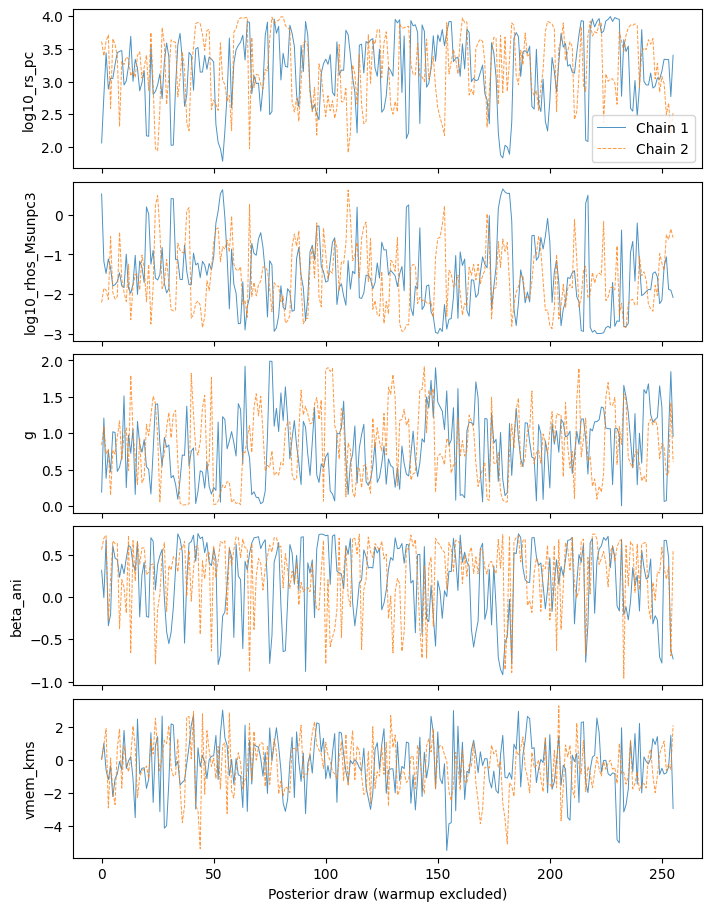

In [5]:
names = ["log10_rs_pc", "log10_rhos_Msunpc3", "g", "beta_ani", "vmem_kms"]
mcmc.print_summary(exclude_deterministic=True)
posterior = mcmc.get_samples(group_by_chain=True)  # Each value: (chain, draw).
for name in names:
    interval = np.quantile(np.asarray(posterior[name]), [.16, .5, .84])
    print(name, "16%, 50%, 84%:", interval)
print("Divergences:", int(mcmc.get_extra_fields()["diverging"].sum()))

traces, axes = plt.subplots(len(names), 1, figsize=(7, 9), sharex=True, layout="constrained")
for i, name in enumerate(names):
    for chain_index, values in enumerate(np.asarray(posterior[name])):
        axes[i].plot(values, alpha=.8, lw=.7,
                     ls=["-", "--"][chain_index], label=f"Chain {chain_index + 1}")
    axes[i].set_ylabel(name)
axes[0].legend()
axes[-1].set_xlabel("Posterior draw (warmup excluded)")
plt.show()

## Check convergence and Monte Carlo precision

Keep `(chain, draw)` axes for diagnostics. Here ArviZ computes **rank-normalized
split R-hat**, bulk ESS, tail ESS for the 5%/95% quantiles, and the Monte Carlo
standard error (MCSE) of the mean. These are more informative than simply
counting draws. The earlier NumPyro text summary uses its own diagnostic
implementation; its rounded R-hat values need not equal this table.

| Diagnostic | What to inspect | If it is poor |
| --- | --- | --- |
| Trace / R-hat | Overlapping, stationary chains; R-hat near 1 (aim below 1.01) | Check separated modes and initial regions; improve parameterization/adaptation |
| Bulk / tail ESS | Sufficient effective draws for central / tail summaries | Increase draws after resolving sampling problems; examine slow correlations |
| MCSE | Simulation error small compared with the precision you need | Run longer when the sampler is otherwise reliable |

For a final analysis, use at least four independently initialized chains;
the two short chains here keep the walkthrough small. A useful initial ESS
target is at least 100 effective draws per chain, then assess MCSE for the
actual reported quantities. See the [Stan diagnostic guidance](https://mc-stan.org/learn-stan/diagnostics-warnings.html)
and [ArviZ R-hat definition](https://python.arviz.org/projects/stats/en/latest/api/generated/arviz_stats.rhat.html).


In [6]:
import arviz as az
import pandas as pd

rows = []
for name in names:
    draws = np.asarray(posterior[name])  # Do not flatten chains here.
    rows.append(dict(parameter=name, r_hat=float(az.rhat(draws, method="rank")),
                     ess_bulk=float(az.ess(draws, method="bulk")),
                     ess_tail=float(az.ess(draws, method="tail", prob=(.05, .95))),
                     mcse_mean=float(az.mcse(draws, method="mean")),
                     posterior_sd=float(np.std(draws, ddof=1))))
diagnostics = pd.DataFrame(rows).set_index("parameter")
diagnostics["mcse_mean / sd"] = diagnostics.mcse_mean / diagnostics.posterior_sd
print(diagnostics.round(4).to_string())
print("Nonfinite diagnostics (investigate):",
      diagnostics.index[~np.isfinite(diagnostics).all(axis=1)].tolist())
print("R-hat >= 1.01:", diagnostics.index[diagnostics.r_hat >= 1.01].tolist())
print("Bulk ESS < 100 per chain:",
      diagnostics.index[diagnostics.ess_bulk < 100*mcmc.num_chains].tolist())
print("Tail ESS < 100 per chain:",
      diagnostics.index[diagnostics.ess_tail < 100*mcmc.num_chains].tolist())


                     r_hat  ess_bulk  ess_tail  mcse_mean  posterior_sd  mcse_mean / sd
parameter                                                                              
log10_rs_pc         1.0054  150.0313  109.4618     0.0393        0.5273          0.0744
log10_rhos_Msunpc3  1.0180  127.3284   88.8019     0.0660        0.8265          0.0799
g                   1.0103  176.6550  221.2711     0.0361        0.4696          0.0768
beta_ani            1.0056  235.8798  194.5926     0.0271        0.4190          0.0648
vmem_kms            1.0030  459.4640  288.3247     0.0743        1.5465          0.0481
Nonfinite diagnostics (investigate): []
R-hat >= 1.01: ['log10_rhos_Msunpc3', 'g']
Bulk ESS < 100 per chain: ['log10_rs_pc', 'log10_rhos_Msunpc3', 'g']
Tail ESS < 100 per chain: ['log10_rs_pc', 'log10_rhos_Msunpc3', 'beta_ani']


## Inspect NUTS divergences, energy and trajectory length

The `extra_fields` argument above records the diagnostics along with sampling;
NumPyro otherwise does not save all of them. A divergence flags an inaccurate
Hamiltonian trajectory and possible sampling bias. Check **post-warmup** counts
per chain and their locations in parameter space, even when R-hat looks good.

BFMI uses **total Hamiltonian energy**, not just potential energy. Values below
about 0.3 merit investigation. The tree-depth count below follows NumPyro's
documented relation to `num_steps`. Reaching the configured depth is an
efficiency warning; it is distinct from a divergence. The mean acceptance
probability is useful context but cannot certify convergence. See
[NumPyro's MCMC fields](https://num.pyro.ai/en/latest/mcmc.html) and the
[ArviZ BFMI definition](https://python.arviz.org/projects/stats/en/latest/api/generated/arviz_stats.bfmi.html).


       divergences  divergence_fraction    BFMI  at_max_tree_depth  mean_accept_prob
chain                                                                               
1                0                  0.0  0.8661                  0            0.9299
2                0                  0.0  0.8393                  0            0.9314
All diagnostics exclude warmup.


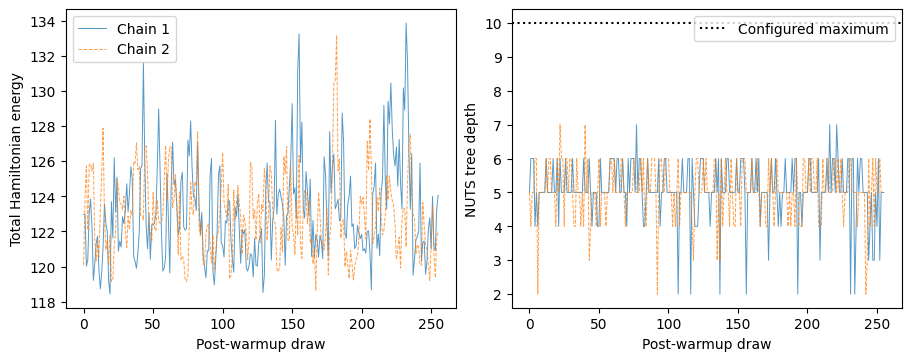

In [7]:
stats = {name: np.asarray(value) for name, value in
         mcmc.get_extra_fields(group_by_chain=True).items()}
diverging = stats["diverging"].astype(bool)
tree_depth = np.floor(np.log2(np.maximum(stats["num_steps"], 1))).astype(int) + 1
bfmi = np.asarray(az.bfmi(stats["energy"]))
nuts_diagnostics = pd.DataFrame({
    "divergences": diverging.sum(axis=1),
    "divergence_fraction": diverging.mean(axis=1),
    "BFMI": bfmi,
    "at_max_tree_depth": (tree_depth >= max_tree_depth).sum(axis=1),
    "mean_accept_prob": stats["accept_prob"].mean(axis=1),
}, index=pd.Index(np.arange(mcmc.num_chains)+1, name="chain"))
print(nuts_diagnostics.round(4).to_string())
print("All diagnostics exclude warmup.")

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5), layout="constrained")
for chain in range(mcmc.num_chains):
    label = f"Chain {chain+1}"
    axes[0].plot(stats["energy"][chain], lw=.7, alpha=.75,
                 ls=["-", "--"][chain], label=label)
    axes[1].plot(tree_depth[chain], lw=.7, alpha=.75,
                 ls=["-", "--"][chain])
axes[0].set(ylabel="Total Hamiltonian energy", xlabel="Post-warmup draw")
axes[0].legend()
axes[1].axhline(max_tree_depth, color="black", ls=":", label="Configured maximum")
axes[1].set(ylabel="NUTS tree depth", xlabel="Post-warmup draw")
axes[1].legend()
plt.show()


## Locate correlations and divergences in a corner plot

The lower triangle shows approximate **68% and 95% enclosed-probability
contours of each 2-D marginal**, estimated from smoothed histograms. They are
not the default Gaussian-radius “1/2 sigma” levels and not a joint region in
all five dimensions. Diagonal dashed lines show 16%, 50% and 84% marginal
quantiles; black lines mark the true parameters. See the
[corner explanation of probability levels](https://corner.readthedocs.io/en/latest/pages/sigmas/).

Flatten only for this plot, keeping the divergence mask in the same chain/draw
order. Red crosses mark flagged post-warmup draws if any exist. If the count is
zero, no red crosses are drawn; this is not a demonstration of a failed run.
Do not discard divergent draws to make the plot look better. Their reported
locations help diagnose geometry but do not trace the entire failed trajectory.


Flagged draws in the corner plot: 0


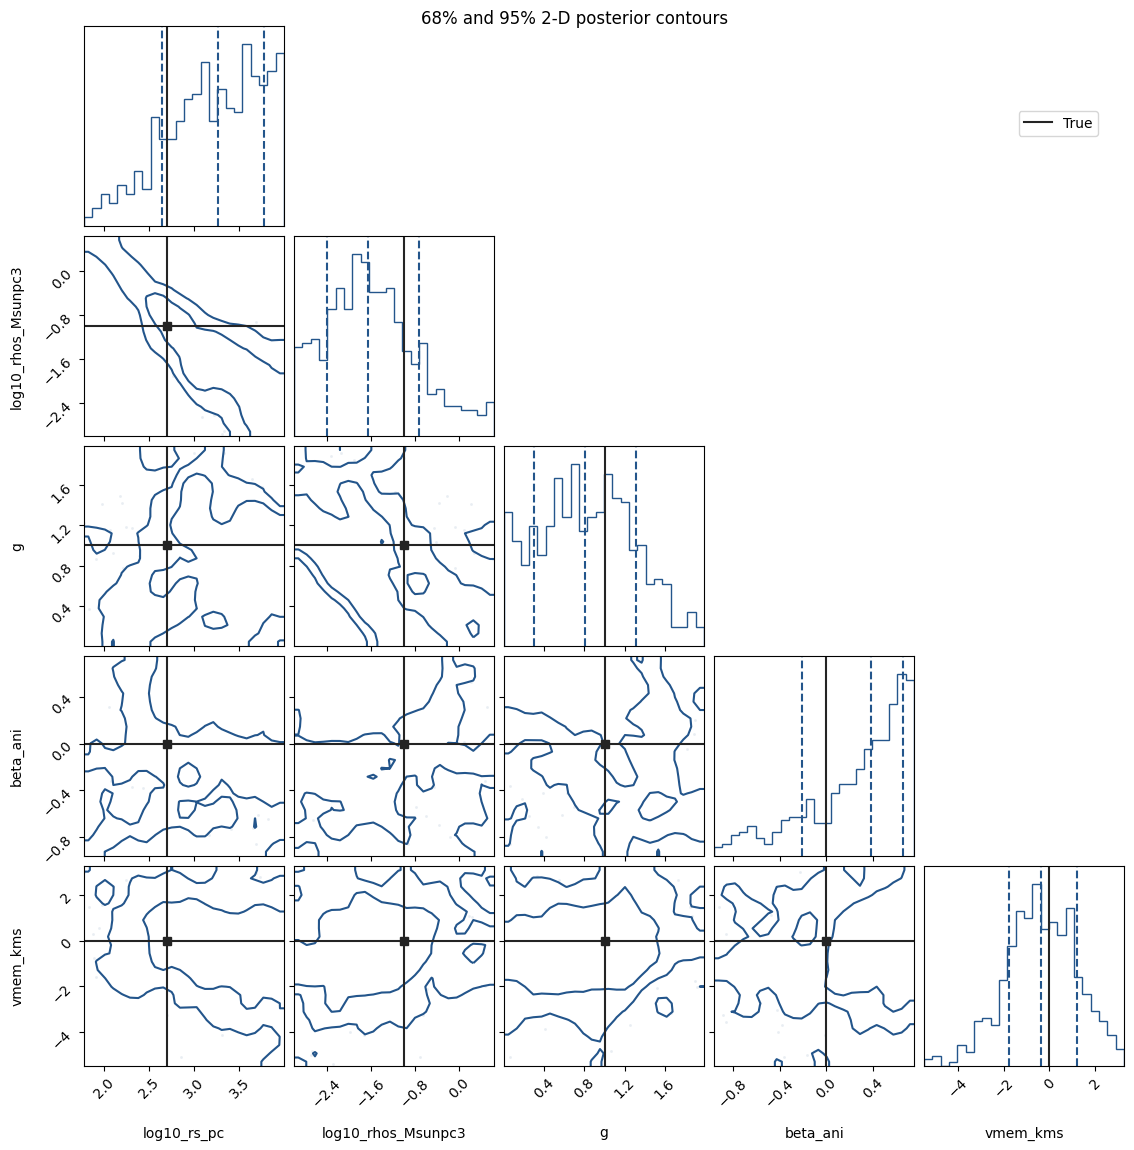

In [8]:
import corner
from matplotlib.lines import Line2D

flat = np.column_stack([np.asarray(posterior[name]).reshape(-1) for name in names])
divergent_flat = diverging.reshape(-1)
true_values = [np.log10(truth["rs_pc"]), np.log10(truth["rhos_Msunpc3"]),
               truth["g"], truth["beta_ani"], 0.]
fig = corner.corner(flat, labels=names, truths=true_values, truth_color="#242424",
                    levels=(.68, .95), bins=24, smooth=1.,
                    quantiles=(.16, .5, .84), color="#23558b",
                    plot_density=False, fill_contours=False,
                    label_kwargs={"fontsize": 10})
axes = np.asarray(fig.axes).reshape(len(names), len(names))
if divergent_flat.any():
    for i in range(len(names)):
        for j in range(i):
            axes[i, j].scatter(flat[divergent_flat, j], flat[divergent_flat, i],
                               marker="x", color="#b64635", s=20, zorder=5)
fig.suptitle("68% and 95% 2-D posterior contours", fontsize=12)
handles = [Line2D([], [], color="#242424", label="True")]
if divergent_flat.any():
    handles.append(Line2D([], [], marker="x", ls="none", color="#b64635", label="Divergent draw"))
fig.legend(handles=handles, loc="upper right", bbox_to_anchor=(.95, .9))
print("Flagged draws in the corner plot:", int(divergent_flat.sum()))
plt.show()


## Decide what to change before trusting the posterior

**Reading the recorded run:** both chains have zero divergences and no
depth-limit hits, and their BFMI values exceed 0.3. Nevertheless,
`log10_rhos_Msunpc3` and `g` have rank-normalized R-hat above 1.01,
and several ESS values fall below the stated target. These short-run
summaries and contours illustrate the workflow; they are not ready
for final inference merely because the divergence count is zero.

If divergences occur, inspect their parameter-space pattern and verify finite,
stable gradients and refined Jeans quadrature. A rerun with
`target_accept_prob=0.9` or `0.95` reduces step sizes, but difficult geometry
may require reparameterization. For this radius/density degeneracy, adapting
a dense mass matrix (`dense_mass=True`) is another option to investigate.
See NumPyro's [posterior geometry tutorial](https://num.pyro.ai/en/latest/tutorials/bad_posterior_geometry.html).
Record the change and compare diagnostics in a fresh run; changing a prior
changes the inferential question and should have scientific justification.

For poor mixing without divergences, try more warmup, dispersed independent
initializations and longer chains. Look for separate modes; blindly increasing
`max_tree_depth` or dropping samples does not address the cause. Review low
BFMI and frequent depth limits together with the geometry and energy traces.

Nonfinite diagnostics are unresolved, not a pass. Use the printed warnings
from this short run as a worked example, not a pass/fail
certificate. Inspect diagnostics for derived profiles too when they are the
quantities to be reported. Good sampler diagnostics do not establish physical
model adequacy or interval calibration; posterior predictive checks and, for
calibration, repeated simulated datasets answer different questions.

The [Quickstart profile plots](../quickstart.ipynb#compare-posterior-profiles-with-the-true-and-map-models)
propagate complete joint draws to dispersion and DM density. Their numerical
MAP curve uses the posterior density in the named sampling coordinates;
the pointwise posterior median generally is not the prediction at a single
median parameter vector.

## Use NumPy/SciPy with emcee

For the classical backend, define the same physical model with stored
parameters and a log posterior that updates them at each call. This example
uses the same five sampling coordinates and Gaussian likelihood:

In [9]:
import emcee
from jeanspy.model import (
    DSphModel, PlummerModel, ZhaoModel, ConstantAnisotropyModel,
)
model = DSphModel(vmem_kms=0., submodels={
    "StellarModel": PlummerModel(re_pc=200.),
    "DMModel": ZhaoModel(rs_pc=500., rhos_Msunpc3=.1,
                         a=1., b=3., g=1., r_t_pc=np.inf),
    "AnisotropyModel": ConstantAnisotropyModel(beta_ani=0.),
})
sigma_kms = np.sqrt(model.sigmalos2(R_pc, n=128, n_kernel=32))

In [10]:
# Sample halo radius, density, inner slope, anisotropy and systemic velocity.
# These illustrative priors are uniform in the named coordinates.
names = ["log10_rs_pc", "log10_rhos_Msunpc3", "g", "beta_ani", "vmem_kms"]
lower = np.array([1.5, -3., 0., -1., -50.])
upper = np.array([4., 1., 2., .75, 50.])


def log_probability(theta):
    if not np.all((lower < theta) & (theta < upper)):
        return -np.inf
    log_rs, log_rho, g, beta, mean = theta
    model.update(rs_pc=10**log_rs, rhos_Msunpc3=10**log_rho,
                 g=g, beta_ani=beta, vmem_kms=mean)
    variance = model.sigmalos2(R_pc, n=128, n_kernel=32) + e_vlos_kms**2
    return -.5 * np.sum(np.log(2*np.pi*variance) + (vlos_kms-mean)**2/variance)

Run the complete file from the checkout to include its imports, common mock
data and output handling:

```bash
python examples/docs_quickstart_emcee.py --output-dir /tmp/jeanspy-emcee-example
```

Use a new output directory. The returned emcee chain has dimensions
`(step, walker, parameter)`; interacting walkers are not independent chains
for R-hat. The JeansPy [`jeanspy.sampler.Sampler`](https://gomeshun.github.io/jeanspy/dev/api/all.html) wrapper adds HDF5
storage and identity checks for supported estimation models. The direct
`emcee.EnsembleSampler` route above lets you supply your own log posterior.
For process pools, use a picklable callable and guard process creation with
`if __name__ == "__main__":`; the local functions in the minimal Quickstart
are not a multiprocessing example.

Next: [save and resume results](storage.ipynb).

## Check the classical sampling interface

This short run exercises the emcee call on the same data. It does not establish convergence.

In [11]:
initial = np.array([np.log10(500.), -1., 1., 0., 0.])
walkers = initial + np.random.default_rng(42).normal(size=(16, len(names))) * [.05, .05, .05, .05, .5]
sampler = emcee.EnsembleSampler(16, len(names), log_probability)
sampler.random_state = np.random.RandomState(42).get_state()
sampler.run_mcmc(walkers, 32, progress=False)
print("(step, walker, parameter):", sampler.get_chain().shape)
assert np.all(np.isfinite(sampler.get_log_prob()))

(step, walker, parameter): (32, 16, 5)
